0.02
3.61
3.61


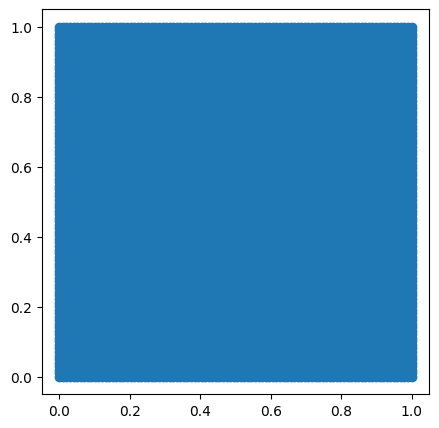

In [9]:
## Import Library
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

## Plate dimensions in Meters
X=1
Y=1
## Simulations Parameters
#mesh size 
del_x=0.01
del_y=0.01
h=0.01
#material properties
E=3e+3
nu=0.3
G=E/((1-nu)*2)
Rho=11000
#speed of wave in medium
ws=(G/Rho)**0.5
# Simulation time in S
c=0.95
delt= round(c*h/ws,2) 
print(delt)
tot_time=10
rx= ((c*delt)/del_x)**2   
ry= ((c*delt)/del_y)**2 
print(rx)    
print(ry)
## Plate with Zero Deformation
x=np.linspace(0,X,100)
y=np.linspace(0,Y,100)
a,b=np.meshgrid(x,y)
plt.figure(figsize=(5,5))
plt.scatter(a,b)
plt.show()

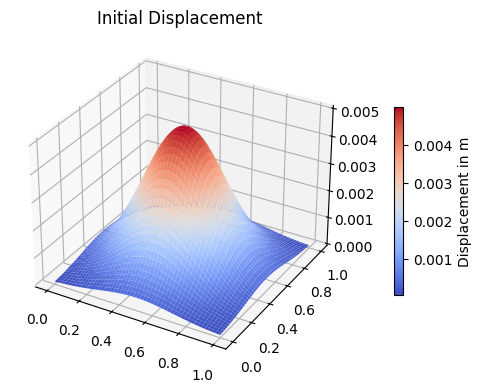

In [10]:
## Initial Condition
Z=(np.exp(-((a-0.5)**2 + (b-0.5)**2)/0.1))/200
Z_previ=Z
Z_crnt=Z_previ
Z_next=np.zeros([100,100])
Z_displacement=[]
## Plot Initial Condition
fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot(111, projection="3d")
surf=ax.plot_surface(a,b,Z,cmap="coolwarm")
fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)

plt.title("Initial Displacement")
plt.tight_layout()
plt.show()

In [11]:
## Solve the Equation with Central Difference Method
for t in range(0,int(tot_time/delt)):
    for i in range(1,99):
        for j in range(1,99):
            Z_disp= 2*Z_crnt[i,j] - 2*Z_previ[i,j] + (rx**2)*(Z_crnt[i+1,j] - 2*Z_crnt[i,j] + Z_crnt[i-1,j]) + (ry**2) * (Z_crnt[i,j+1] - 2*Z_crnt[i,j] + Z_crnt[i,j-1])
            Z_next[i][j]=Z_disp
    print(Z_next)
    Z_previ= Z_crnt.copy()
    Z_crnt=Z_next.copy()
    Z_displacement.append(Z_crnt)
    

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 8.31541402e-06 8.93456557e-06 ... 8.93456557e-06
  8.31541402e-06 0.00000000e+00]
 [0.00000000e+00 8.93456557e-06 9.59308832e-06 ... 9.59308832e-06
  8.93456557e-06 0.00000000e+00]
 ...
 [0.00000000e+00 8.93456557e-06 9.59308832e-06 ... 9.59308832e-06
  8.93456557e-06 0.00000000e+00]
 [0.00000000e+00 8.31541402e-06 8.93456557e-06 ... 8.93456557e-06
  8.31541402e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -2.66261887e-04 -1.80420523e-04 ... -1.80420523e-04
  -2.66261887e-04  0.00000000e+00]
 [ 0.00000000e+00 -1.80420523e-04 -8.02426623e-05 ... -8.02426623e-05
  -1.80420523e-04  0.00000000e+00]
 ...
 [ 0.00000000e+00 -1.80420523e-04 -8.02426623e-05 ... -8.02426623e-05
  -1.80420

C:\Users\622009\AppData\Local\Temp\ipykernel_29580\4229733058.py:5: RuntimeWarning: overflow encountered in scalar add
  Z_disp= 2*Z_crnt[i,j] - 2*Z_previ[i,j] + (rx**2)*(Z_crnt[i+1,j] - 2*Z_crnt[i,j] + Z_crnt[i-1,j]) + (ry**2) * (Z_crnt[i,j+1] - 2*Z_crnt[i,j] + Z_crnt[i,j-1])
C:\Users\622009\AppData\Local\Temp\ipykernel_29580\4229733058.py:5: RuntimeWarning: overflow encountered in scalar multiply
  Z_disp= 2*Z_crnt[i,j] - 2*Z_previ[i,j] + (rx**2)*(Z_crnt[i+1,j] - 2*Z_crnt[i,j] + Z_crnt[i-1,j]) + (ry**2) * (Z_crnt[i,j+1] - 2*Z_crnt[i,j] + Z_crnt[i,j-1])
C:\Users\622009\AppData\Local\Temp\ipykernel_29580\4229733058.py:5: RuntimeWarning: invalid value encountered in scalar add
  Z_disp= 2*Z_crnt[i,j] - 2*Z_previ[i,j] + (rx**2)*(Z_crnt[i+1,j] - 2*Z_crnt[i,j] + Z_crnt[i-1,j]) + (ry**2) * (Z_crnt[i,j+1] - 2*Z_crnt[i,j] + Z_crnt[i,j-1])
C:\Users\622009\AppData\Local\Temp\ipykernel_29580\4229733058.py:5: RuntimeWarning: overflow encountered in scalar subtract
  Z_disp= 2*Z_crnt[i,j] - 2*Z_pr

[[ 0.00000000e+000  0.00000000e+000  0.00000000e+000 ...  0.00000000e+000
   0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000 -1.54525478e+308              inf ...              inf
  -1.54525478e+308  0.00000000e+000]
 [ 0.00000000e+000              inf             -inf ...             -inf
               inf  0.00000000e+000]
 ...
 [ 0.00000000e+000              inf             -inf ...             -inf
               inf  0.00000000e+000]
 [ 0.00000000e+000 -1.54525478e+308              inf ...              inf
  -1.54525478e+308  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000 ...  0.00000000e+000
   0.00000000e+000  0.00000000e+000]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 ...
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 ...
 [ 0. nan nan ... nan nan  0.]
 [ 0. n

C:\Users\622009\AppData\Local\Temp\ipykernel_29580\4229733058.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  Z_disp= 2*Z_crnt[i,j] - 2*Z_previ[i,j] + (rx**2)*(Z_crnt[i+1,j] - 2*Z_crnt[i,j] + Z_crnt[i-1,j]) + (ry**2) * (Z_crnt[i,j+1] - 2*Z_crnt[i,j] + Z_crnt[i,j-1])


[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 ...
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 ...
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 ...
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 ...
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 ...
 [ 0. nan nan ... nan nan  0.]
 [ 0. nan nan ... nan nan  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0. nan

C:\Users\622009\AppData\Local\Temp\ipykernel_29580\2501309783.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 500x500 with 2 Axes> than <Figure size 500x500 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)
C:\Users\622009\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


ValueError: Axis limits cannot be NaN or Inf

C:\Users\622009\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\colors.py:2294: RuntimeWarning: overflow encountered in subtract
  resdat -= vmin
C:\Users\622009\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\colors.py:2295: RuntimeWarning: overflow encountered in scalar subtract
  resdat /= (vmax - vmin)
C:\Users\622009\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


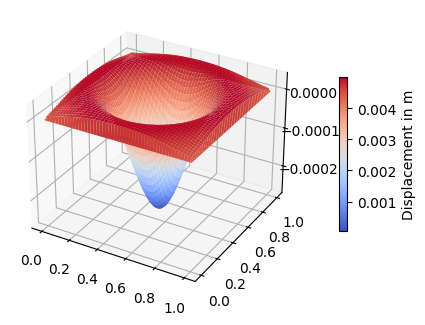

In [12]:
## Create Animation:
fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot(111,projection="3d")
ax.plot_surface(a,b,Z_displacement[0], cmap="coolwarm")
fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)
ax.set_title("Vibration of Plate")

def animate(i):
    ax.clear()
    ax.plot_surface(a,b,Z_displacement[i], cmap="coolwarm")

anim=animation.FuncAnimation(fig,animate,frames=range(0,int(tot_time/delt),5))
writer=animation.PillowWriter(fps=(90))
anim.save("Vibration_of_Plate.gif",writer=writer)

In [ ]:
print(Z_displacement)